# 📊 Google Maps Reviews - Visualisations Logiques

Analyse et visualisations complètes du dataset Google Maps nettoyé

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from textblob import TextBlob
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

# Styles
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)

print("✅ Libraries loaded")

✅ Libraries loaded


In [2]:
# Load cleaned data
df = pd.read_csv('Data/google_maps_reviews_cleaned.csv')

print(f"📊 Dataset loaded: {len(df)} reviews")
print(f"Locations: {df['location'].nunique()}")
print(f"Reviewers: {df['reviewer_id'].nunique()}\n")

# Extract features
df['content_length'] = df['content'].str.len()
df['word_count'] = df['content'].str.split().str.len()

# Simple sentiment analysis
def get_sentiment(text):
    try:
        blob = TextBlob(str(text))
        return blob.sentiment.polarity
    except:
        return 0

df['sentiment'] = df['content'].apply(get_sentiment)
df['sentiment_label'] = df['sentiment'].apply(
    lambda x: 'Positif ✅' if x > 0.15 else 'Négatif ❌' if x < -0.15 else 'Neutre 😐'
)

print(f"✅ Features extracted\n")
print(df.head(3))

📊 Dataset loaded: 204 reviews
Locations: 29
Reviewers: 127

✅ Features extracted

  location    reviewer_id                                            content  \
0    Blida       علي زبير                                        استقبال جيد   
1    Blida  LAMINE KEBBAB                                                3.5   
2    Blida      Midou Sou  J'ai passé chez un jeune homme, il est très se...   

   content_length  word_count  sentiment sentiment_label  
0              11           2        0.0        Neutre 😐  
1               3           1        0.0        Neutre 😐  
2              54          10        0.0        Neutre 😐  


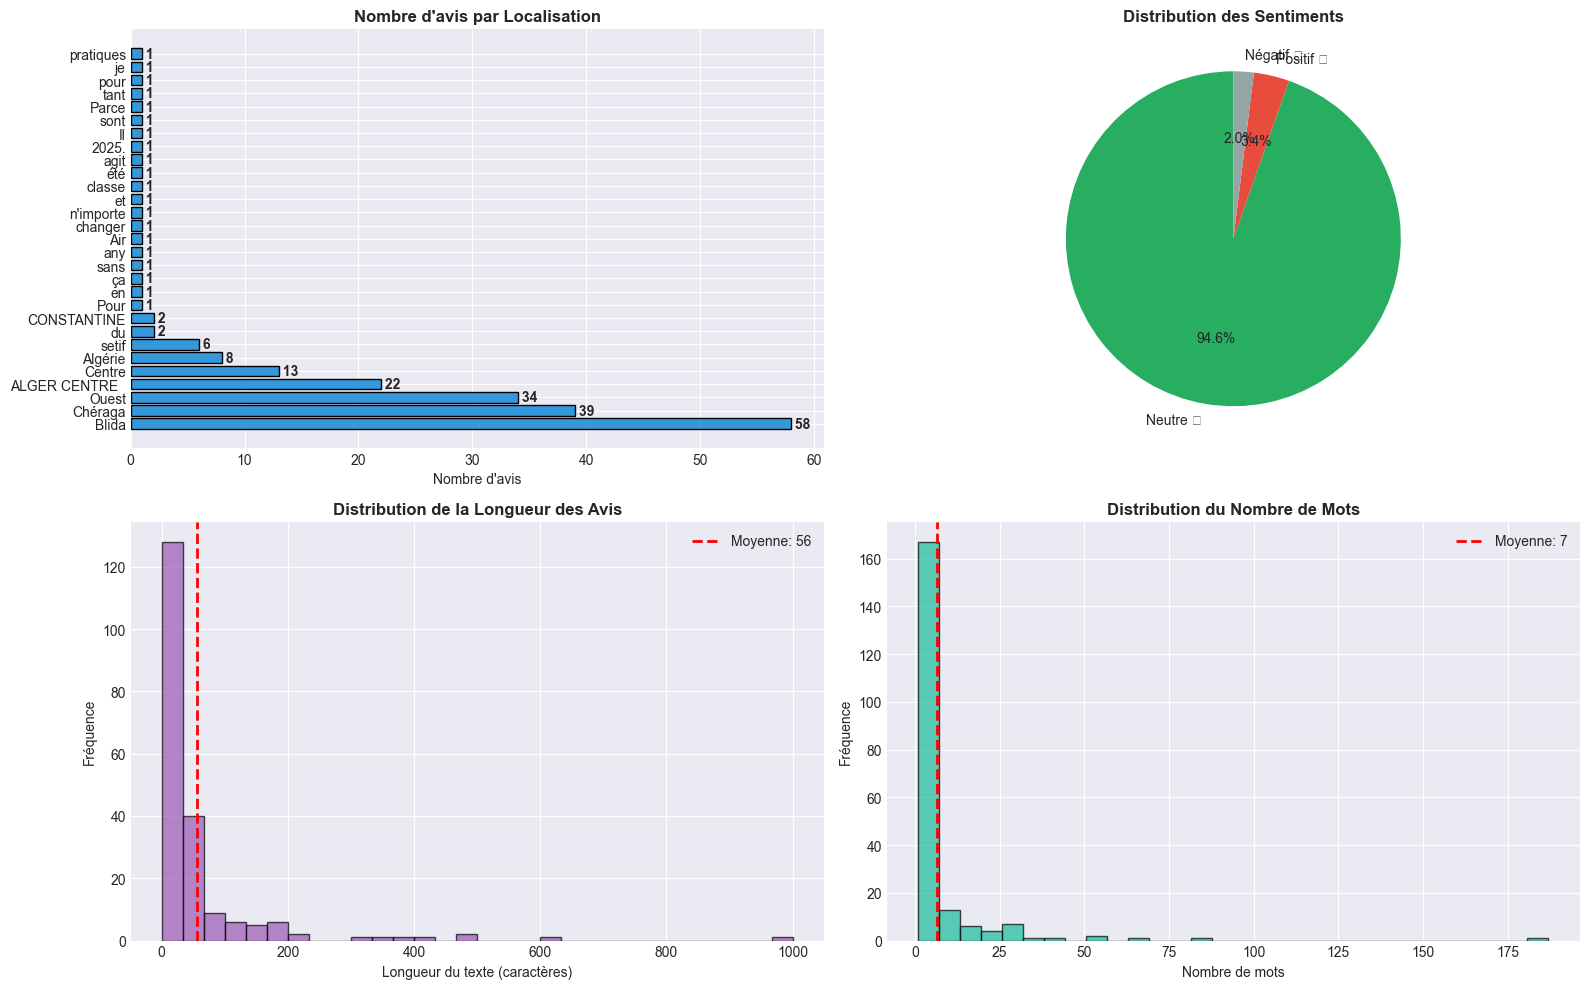

✅ Overview visualization saved: google_maps_overview.png


In [3]:
## 📈 Distribution par Localisation

# 1. Reviews by location
fig, axs = plt.subplots(2, 2, figsize=(16, 10))

# Count by location
location_counts = df['location'].value_counts()
axs[0,0].barh(location_counts.index, location_counts.values, color='#3498db', edgecolor='black')
axs[0,0].set_xlabel('Nombre d\'avis')
axs[0,0].set_title('Nombre d\'avis par Localisation', fontweight='bold', fontsize=12)
for i, v in enumerate(location_counts.values):
    axs[0,0].text(v, i, f' {v}', va='center', fontweight='bold')

# Sentiment distribution
sentiment_dist = df['sentiment_label'].value_counts()
colors_sent = ['#27ae60', '#e74c3c', '#95a5a6']
axs[0,1].pie(sentiment_dist.values, labels=sentiment_dist.index, autopct='%1.1f%%', colors=colors_sent, startangle=90)
axs[0,1].set_title('Distribution des Sentiments', fontweight='bold', fontsize=12)

# Content length distribution
axs[1,0].hist(df['content_length'], bins=30, color='#9b59b6', edgecolor='black', alpha=0.7)
axs[1,0].axvline(df['content_length'].mean(), color='red', linestyle='--', linewidth=2, label=f'Moyenne: {df["content_length"].mean():.0f}')
axs[1,0].set_xlabel('Longueur du texte (caractères)')
axs[1,0].set_ylabel('Fréquence')
axs[1,0].set_title('Distribution de la Longueur des Avis', fontweight='bold', fontsize=12)
axs[1,0].legend()

# Word count distribution
axs[1,1].hist(df['word_count'], bins=30, color='#1abc9c', edgecolor='black', alpha=0.7)
axs[1,1].axvline(df['word_count'].mean(), color='red', linestyle='--', linewidth=2, label=f'Moyenne: {df["word_count"].mean():.0f}')
axs[1,1].set_xlabel('Nombre de mots')
axs[1,1].set_ylabel('Fréquence')
axs[1,1].set_title('Distribution du Nombre de Mots', fontweight='bold', fontsize=12)
axs[1,1].legend()

plt.tight_layout()
plt.savefig('google_maps_overview.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Overview visualization saved: google_maps_overview.png")

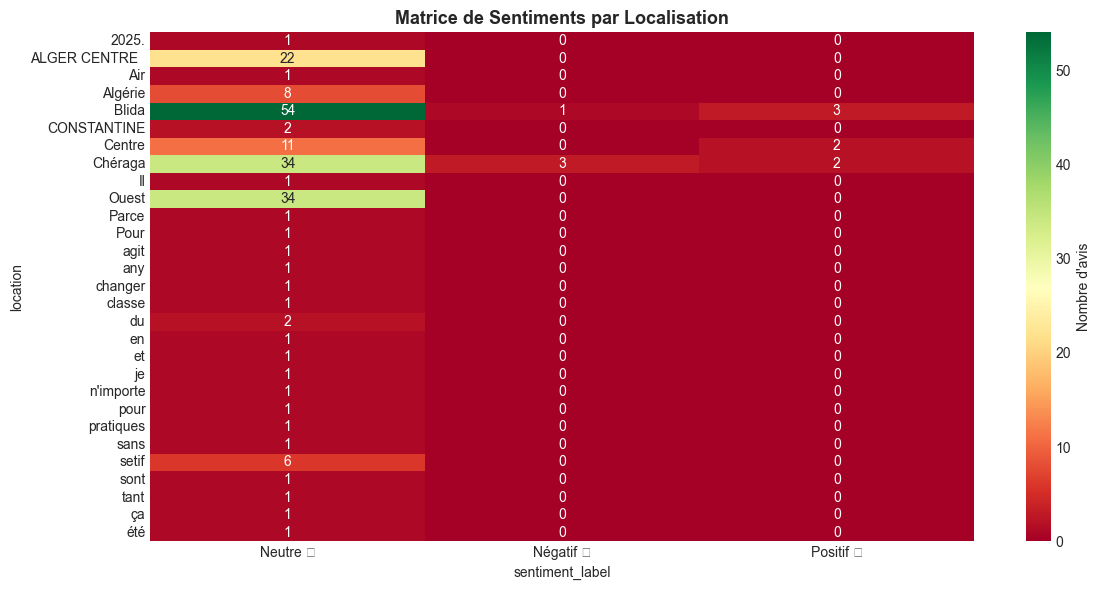

✅ Sentiment heatmap saved: sentiment_by_location.png


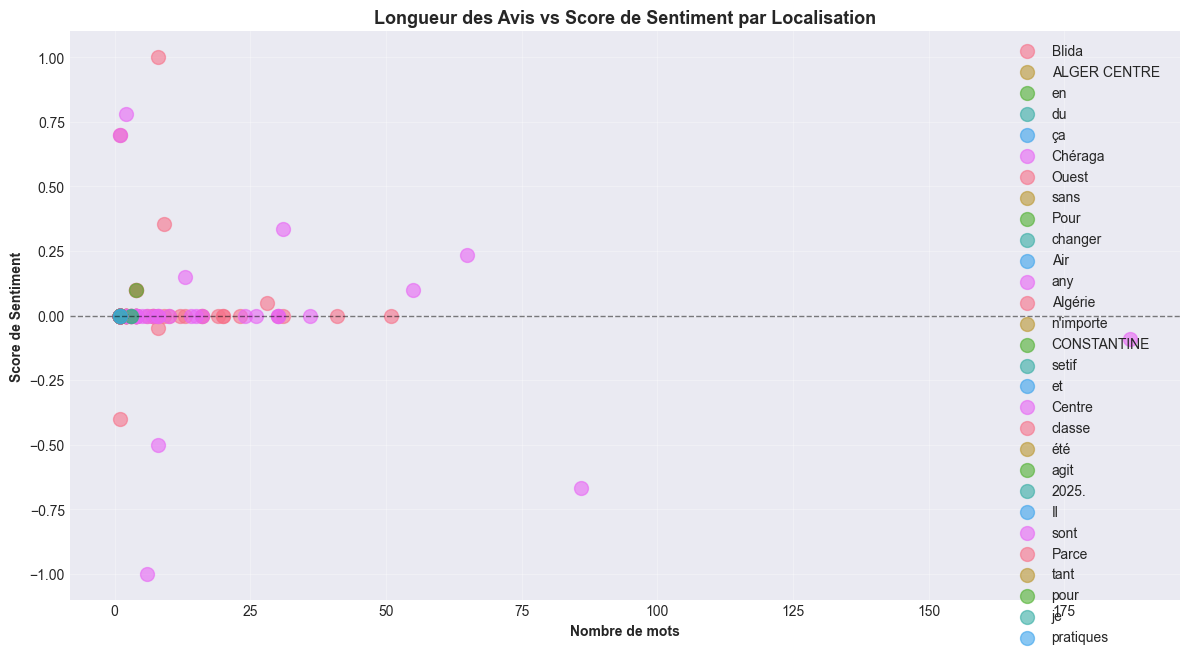

✅ Sentiment scatter saved: sentiment_vs_length_location.png


In [4]:
## 🎯 Sentiments par Localisation

# Heatmap sentiment by location
fig, ax = plt.subplots(figsize=(12, 6))
sentiment_by_location = pd.crosstab(df['location'], df['sentiment_label'])
sns.heatmap(sentiment_by_location, annot=True, fmt='d', cmap='RdYlGn', ax=ax, cbar_kws={'label': 'Nombre d\'avis'})
ax.set_title('Matrice de Sentiments par Localisation', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('sentiment_by_location.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Sentiment heatmap saved: sentiment_by_location.png")

# Sentiment score scatter
fig, ax = plt.subplots(figsize=(12, 7))
for location in df['location'].unique():
    data = df[df['location'] == location]
    ax.scatter(data['word_count'], data['sentiment'], alpha=0.6, s=100, label=location)
    
ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('Nombre de mots', fontweight='bold')
ax.set_ylabel('Score de Sentiment', fontweight='bold')
ax.set_title('Longueur des Avis vs Score de Sentiment par Localisation', fontweight='bold', fontsize=13)
ax.legend(loc='best')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('sentiment_vs_length_location.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Sentiment scatter saved: sentiment_vs_length_location.png")

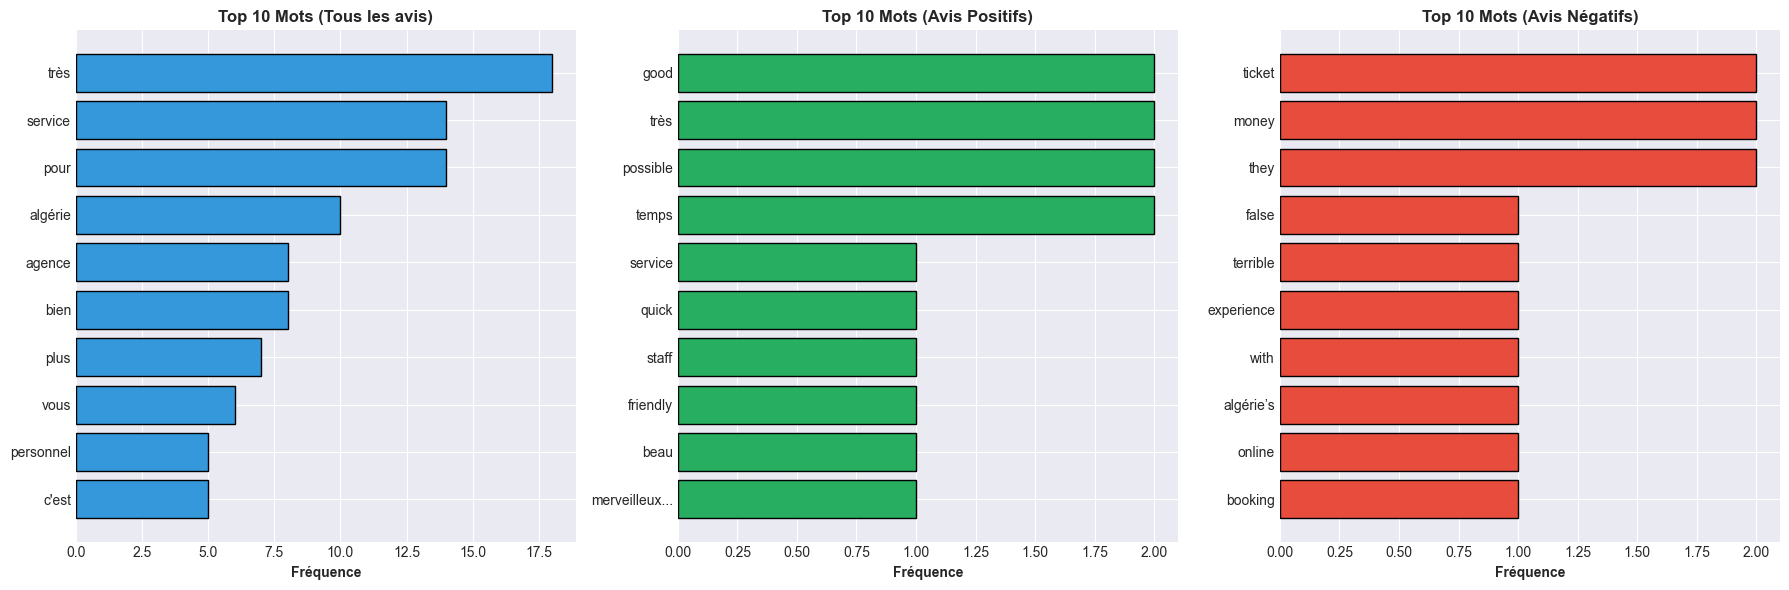

✅ Words analysis saved: top_words_analysis.png


In [5]:
## 📝 Analyse des Mots les Plus Fréquents

# Top words overall
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# All words
all_words = ' '.join(df['content'].str.lower()).split()
all_words = [w for w in all_words if len(w) > 3]  # Filter short words
top_words = Counter(all_words).most_common(10)

words_all = [w[0] for w in top_words]
counts_all = [w[1] for w in top_words]
axs[0].barh(words_all, counts_all, color='#3498db', edgecolor='black')
axs[0].set_xlabel('Fréquence', fontweight='bold')
axs[0].set_title('Top 10 Mots (Tous les avis)', fontweight='bold')
axs[0].invert_yaxis()

# Positive reviews
pos_words = ' '.join(df[df['sentiment'] > 0.15]['content'].str.lower()).split()
pos_words = [w for w in pos_words if len(w) > 3]
top_pos = Counter(pos_words).most_common(10)

words_pos = [w[0] for w in top_pos]
counts_pos = [w[1] for w in top_pos]
axs[1].barh(words_pos, counts_pos, color='#27ae60', edgecolor='black')
axs[1].set_xlabel('Fréquence', fontweight='bold')
axs[1].set_title('Top 10 Mots (Avis Positifs)', fontweight='bold')
axs[1].invert_yaxis()

# Negative reviews
neg_words = ' '.join(df[df['sentiment'] < -0.15]['content'].str.lower()).split()
neg_words = [w for w in neg_words if len(w) > 3]
top_neg = Counter(neg_words).most_common(10)

words_neg = [w[0] for w in top_neg]
counts_neg = [w[1] for w in top_neg]
axs[2].barh(words_neg, counts_neg, color='#e74c3c', edgecolor='black')
axs[2].set_xlabel('Fréquence', fontweight='bold')
axs[2].set_title('Top 10 Mots (Avis Négatifs)', fontweight='bold')
axs[2].invert_yaxis()

plt.tight_layout()
plt.savefig('top_words_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Words analysis saved: top_words_analysis.png")

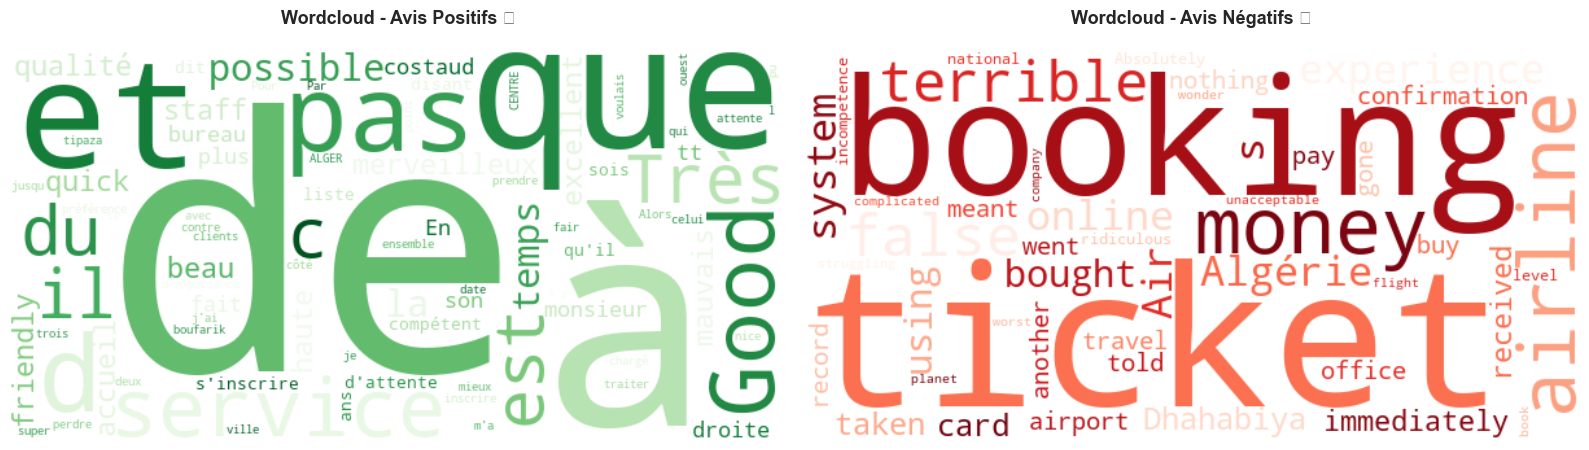

✅ Wordclouds saved: wordclouds_google_maps.png


In [6]:
## ☁️ Wordclouds

# Try to install wordcloud if not available
try:
    from wordcloud import WordCloud
    
    # Positive reviews wordcloud
    pos_text = ' '.join(df[df['sentiment'] > 0.15]['content'])
    wc_pos = WordCloud(width=600, height=300, background_color='white', colormap='Greens').generate(pos_text)
    
    # Negative reviews wordcloud
    neg_text = ' '.join(df[df['sentiment'] < -0.15]['content'])
    wc_neg = WordCloud(width=600, height=300, background_color='white', colormap='Reds').generate(neg_text)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    ax1.imshow(wc_pos, interpolation='bilinear')
    ax1.axis('off')
    ax1.set_title('Wordcloud - Avis Positifs ✅', fontsize=13, fontweight='bold', pad=20)
    
    ax2.imshow(wc_neg, interpolation='bilinear')
    ax2.axis('off')
    ax2.set_title('Wordcloud - Avis Négatifs ❌', fontsize=13, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.savefig('wordclouds_google_maps.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✅ Wordclouds saved: wordclouds_google_maps.png")
except ImportError:
    print("⚠️ WordCloud not available, skipping this visualization")

In [7]:
## 🎛️ Visualisations Interactives

# 1. Bar chart by location and sentiment
fig1 = px.bar(df.groupby(['location', 'sentiment_label']).size().reset_index(name='count'),
             x='location', y='count', color='sentiment_label',
             title='Nombre d\'Avis par Localisation et Sentiment',
             barmode='group',
             color_discrete_map={'Positif ✅': '#27ae60', 'Négatif ❌': '#e74c3c', 'Neutre 😐': '#95a5a6'},
             height=500)
fig1.write_html('location_sentiment_bar.html')
print("✅ Interactive bar chart saved: location_sentiment_bar.html")

# 2. Box plot - content length by sentiment
fig2 = px.box(df, x='sentiment_label', y='content_length',
             title='Distribution de la Longueur des Avis par Sentiment',
             color='sentiment_label',
             color_discrete_map={'Positif ✅': '#27ae60', 'Négatif ❌': '#e74c3c', 'Neutre 😐': '#95a5a6'},
             height=500)
fig2.write_html('length_sentiment_boxplot.html')
print("✅ Interactive boxplot saved: length_sentiment_boxplot.html")

# 3. Scatter plot
fig3 = px.scatter(df, x='word_count', y='sentiment', 
                 color='location', size='content_length',
                 hover_data=['sentiment_label'],
                 title='Relation: Nombre de Mots vs Score de Sentiment',
                 height=600, width=900)
fig3.write_html('scatter_metrics.html')
print("✅ Interactive scatter saved: scatter_metrics.html")

✅ Interactive bar chart saved: location_sentiment_bar.html
✅ Interactive boxplot saved: length_sentiment_boxplot.html
✅ Interactive scatter saved: scatter_metrics.html


In [8]:
## 📋 Rapport Récapitulatif

print("\n" + "="*80)
print("📊 RAPPORT COMPLET - GOOGLE MAPS REVIEWS".center(80))
print("="*80)

print("\n📈 STATISTIQUES GLOBALES")
print("-" * 80)
print(f"Total d'avis: {len(df)}")
print(f"Nombre de localités: {df['location'].nunique()}")
print(f"Nombre de reviewers: {df['reviewer_id'].nunique()}")
print(f"Longueur moyenne des avis: {df['content_length'].mean():.0f} caractères")
print(f"Nombre moyen de mots: {df['word_count'].mean():.1f} mots")
print(f"Score de sentiment moyen: {df['sentiment'].mean():.3f}")

print("\n😊 DISTRIBUTION DES SENTIMENTS")
print("-" * 80)
for label, count in df['sentiment_label'].value_counts().items():
    pct = count / len(df) * 100
    print(f"  {label:.<30} {count:>3} ({pct:>5.1f}%)")

print("\n📍 AVIS PAR LOCALISATION")
print("-" * 80)
for loc, count in df['location'].value_counts().items():
    avg_sentiment = df[df['location'] == loc]['sentiment'].mean()
    sentiment_emoji = '✅' if avg_sentiment > 0.15 else '❌' if avg_sentiment < -0.15 else '😐'
    print(f"  {loc:.<30} {count:>3} avis | Sentiment moyen: {avg_sentiment:>7.3f} {sentiment_emoji}")

print("\n🎯 OBSERVATIONS CLÉS")
print("-" * 80)
obs = [
    f"Longueur moyenne des avis positifs: {df[df['sentiment']>0.15]['content_length'].mean():.0f} caractères",
    f"Longueur moyenne des avis négatifs: {df[df['sentiment']<-0.15]['content_length'].mean():.0f} caractères",
    f"Reviewer le plus actif: {df['reviewer_id'].value_counts().index[0]} ({df['reviewer_id'].value_counts().values[0]} avis)",
    f"Localité avec le plus d'avis: {df['location'].value_counts().index[0]} ({df['location'].value_counts().values[0]} avis)",
]
for i, obs_text in enumerate(obs, 1):
    print(f"  • {obs_text}")

print("\n✅ FICHIERS GÉNÉRÉS")
print("-" * 80)
files = [
    "google_maps_overview.png - Vue d'ensemble des données",
    "sentiment_by_location.png - Matrice sentiments/localisations",
    "sentiment_vs_length_location.png - Scatter longueur vs sentiment",
    "top_words_analysis.png - Top mots par sentiment",
    "wordclouds_google_maps.png - Nuages de mots",
    "location_sentiment_bar.html - Graphique interactif",
    "length_sentiment_boxplot.html - Boxplot interactif",
    "scatter_metrics.html - Scatter interactif",
]
for f in files:
    print(f"  ✓ {f}")

print("\n" + "="*80)
print("✨ ANALYSE COMPLÈTE TERMINÉE".center(80))
print("="*80)


                    📊 RAPPORT COMPLET - GOOGLE MAPS REVIEWS                     

📈 STATISTIQUES GLOBALES
--------------------------------------------------------------------------------
Total d'avis: 204
Nombre de localités: 29
Nombre de reviewers: 127
Longueur moyenne des avis: 56 caractères
Nombre moyen de mots: 6.6 mots
Score de sentiment moyen: 0.010

😊 DISTRIBUTION DES SENTIMENTS
--------------------------------------------------------------------------------
  Neutre 😐...................... 193 ( 94.6%)
  Positif ✅.....................   7 (  3.4%)
  Négatif ❌.....................   4 (  2.0%)

📍 AVIS PAR LOCALISATION
--------------------------------------------------------------------------------
  Blida.........................  58 avis | Sentiment moyen:   0.030 😐
  Chéraga.......................  39 avis | Sentiment moyen:  -0.037 😐
  Ouest.........................  34 avis | Sentiment moyen:   0.000 😐
  ALGER CENTRE  ................  22 avis | Sentiment moyen:   0.000 😐
 